In [ ]:
import os
import re
import chess.pgn
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
import scipy.stats as stats
from sklearn.model_selection import train_test_split
import random

# ==========================================
# 1. PARSING & EXTRACTION HELPERS
# ==========================================
def parse_time_control(tc_str):
    """Extracts Base Time and Increment."""
    if not tc_str or tc_str == '-' or '+' not in str(tc_str):
        return None, None
    try:
        base, inc = str(tc_str).split('+')
        return float(base), float(inc)
    except ValueError:
        return None, None

def parse_clock(clk_str):
    """Extracts remaining time in seconds."""
    if not clk_str:
        return 0.0
    match = re.search(r'\[%clk\s+([\d:]+)\]', str(clk_str))
    if match:
        parts = match.group(1).split(':')
        if len(parts) == 3:
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
        elif len(parts) == 2:
            return int(parts[0]) * 60 + float(parts[1])
    return 0.0

def parse_eval(comment_str):
    """
    Extracts Lichess Stockfish evaluations [%eval 1.25] or [%eval #-3].
    Caps mate scores at +/- 15.0 to prevent exploding math.
    """
    if not comment_str:
        return 0.0
    match = re.search(r'\[%eval\s+([#\-\d\.]+)\]', str(comment_str))
    if match:
        val = match.group(1)
        if '#' in val: # It's a forced mate (e.g., #-3 means Black mates in 3)
            return 15.0 if '-' not in val else -15.0
        else:
            # Clamp normal evaluations between -15.0 and 15.0
            score = float(val)
            return max(-15.0, min(15.0, score))
    return 0.0 # If no eval exists, assume an even game (0.0)

class ChessVocabulary:
    def __init__(self):
        self.move_to_id = {"<PAD>": 0, "<UNK>": 1}
        self.eco_to_id = {"<UNK>": 0}
        self.move_idx = 2
        self.eco_idx = 1
        
    def add_move(self, move):
        if move not in self.move_to_id:
            self.move_to_id[move] = self.move_idx
            self.move_idx += 1
            
    def add_eco(self, eco):
        if eco not in self.eco_to_id:
            self.eco_to_id[eco] = self.eco_idx
            self.eco_idx += 1
            
    def encode_moves(self, move_sequence):
        return [self.move_to_id.get(move, self.move_to_id["<UNK>"]) for move in move_sequence]
    
    def encode_eco(self, eco):
        return self.eco_to_id.get(eco, 0)

In [20]:
# ==========================================
# 2. DATA INGESTION PIPELINE
# ==========================================
current_notebook_dir = Path(os.getcwd())
DATA_DIR = current_notebook_dir.parents[1] / "data" / "elias_data"
PGN_FILE_PATH = DATA_DIR / "lichess_db_standard_rated_2017-05.pgn"
PICKLE_PATH = DATA_DIR / "chess_data_full_1mil_2017-05.pkl"

def extract_game_data(game):
    features = {}
    headers = dict(game.headers)
    
    features['WhiteElo'] = int(headers.get('WhiteElo', 0)) if headers.get('WhiteElo', '?').isdigit() else None
    features['ECO'] = headers.get('ECO', 'A00')
    features['TimeControl'] = headers.get('TimeControl', '300+0')
    
    if features['WhiteElo'] is None:
        return None # Skip games with corrupted Elos

    moves, clocks, evals = [], [], []
    node = game
    while not node.is_end():
        next_node = node.next()
        comment = next_node.comment
        
        moves.append(str(next_node.move))
        clocks.append(parse_clock(comment))
        evals.append(parse_eval(comment))
        node = next_node
        
    features['moves'] = moves
    features['clocks'] = clocks
    features['evals'] = evals
    return features

if PICKLE_PATH.exists():
    print(f"Loading cached data from {PICKLE_PATH}...")
    df = pd.read_pickle(PICKLE_PATH)
else:
    print(f"Parsing PGN file...")
    all_games = []
    with open(PGN_FILE_PATH, "r", encoding="utf-8") as pgn_file:
        for i in range(1000000): # Process 100k games
            game = chess.pgn.read_game(pgn_file)
            if game is None: break
            
            data = extract_game_data(game)
            if data is not None:
                all_games.append(data)
                
            if (i + 1) % 10000 == 0:
                print(f"Parsed {i + 1} games...")

    df = pd.DataFrame(all_games)
    df.to_pickle(PICKLE_PATH)
    
print(f"Data ready. Total games: {len(df)}")

Parsing PGN file...
Parsed 10000 games...
Parsed 20000 games...
Parsed 30000 games...
Parsed 40000 games...
Parsed 50000 games...
Parsed 60000 games...
Parsed 70000 games...
Parsed 80000 games...
Parsed 90000 games...
Parsed 100000 games...
Parsed 110000 games...
Parsed 120000 games...
Parsed 130000 games...
Parsed 140000 games...
Parsed 150000 games...
Parsed 160000 games...
Parsed 170000 games...
Parsed 180000 games...
Parsed 190000 games...
Parsed 200000 games...
Parsed 210000 games...
Parsed 220000 games...
Parsed 230000 games...
Parsed 240000 games...
Parsed 250000 games...
Parsed 260000 games...
Parsed 270000 games...
Parsed 280000 games...
Parsed 290000 games...
Parsed 300000 games...
Parsed 310000 games...
Parsed 320000 games...
Parsed 330000 games...
Parsed 340000 games...
Parsed 350000 games...
Parsed 360000 games...
Parsed 370000 games...
Parsed 380000 games...
Parsed 390000 games...
Parsed 400000 games...
Parsed 410000 games...
Parsed 420000 games...
Parsed 430000 games...


In [21]:
# Create a boolean mask: True if the game has evaluations, False if it's all 0.0s
has_eval_mask = df['evals'].apply(lambda evals: sum(abs(e) for e in evals) > 0.0)

# Count the results
games_with_evals = has_eval_mask.sum()
total_games = len(df)
games_without_evals = total_games - games_with_evals
percentage = (games_with_evals / total_games) * 100

print("--- Engine Evaluation Check ---")
print(f"Total Games Parsed: {total_games}")
print(f"Games WITH Engine Evals: {games_with_evals} ({percentage:.1f}%)")
print(f"Games WITHOUT Engine Evals: {games_without_evals} ({(100 - percentage):.1f}%)")

--- Engine Evaluation Check ---
Total Games Parsed: 1000000
Games WITH Engine Evals: 84277 (8.4%)
Games WITHOUT Engine Evals: 915723 (91.6%)


In [ ]:


# ==========================================
# 3. PYTORCH DATASET & DATALOADERS
# ==========================================

print("Splitting Dataset based on Engine Evaluations...")

# 1. SPLIT THE DATAFRAME
has_eval_mask = df['evals'].apply(lambda evals: sum(abs(e) for e in evals) > 0.0)

# Train on all games WITH evaluations
df_train = df[has_eval_mask].copy()

# Grab 40,000 random games WITHOUT evaluations
df_unseen = df[~has_eval_mask].sample(n=min(40000, len(df[~has_eval_mask])), random_state=42).copy()

# Split the unseen games exactly in half (50% Validation, 50% Test)
df_val, df_test = train_test_split(df_unseen, test_size=0.5, random_state=42)

print(f"Training on {len(df_train)} games WITH Stockfish Evals.")
print(f"Validating on {len(df_val)} games WITHOUT Stockfish Evals.")
print(f"Testing on {len(df_test)} games WITHOUT Stockfish Evals.")


# 2. THE DATASET CLASS
class AdvancedChessDataset(Dataset):
    def __init__(self, df, vocab, is_training=True, eval_dropout_rate=0.20):
        self.vocab = vocab
        self.data = []
        self.is_training = is_training
        self.elo_buckets = np.arange(0, 4000, 100)
        
        for _, row in df.iterrows():
            moves = row['moves']
            raw_clocks = row['clocks']
            raw_evals = row['evals']
            
            if len(moves) < 5: continue 
                
            # Prevent Data Leakage: Only build vocab on training data
            if self.is_training:
                for m in moves: self.vocab.add_move(m)
                self.vocab.add_eco(row['ECO'])
            
            # Time Deltas
            base_time, increment = parse_time_control(row['TimeControl'])
            if base_time is None or base_time <= 0:
                base_time, increment = 300.0, 0.0

            time_spent = []
            for i, clock in enumerate(raw_clocks):
                if i < 2:
                    spent = base_time - clock
                else:
                    spent = (raw_clocks[i-2] - clock) + increment
                time_spent.append(max(0.0, spent) / base_time) 
                
            turns = [idx % 2 for idx in range(len(moves))]
            
            # Eval Dropout
            if self.is_training and random.random() < eval_dropout_rate:
                norm_evals = [0.0] * len(raw_evals) 
            else:
                norm_evals = [e / 15.0 for e in raw_evals] 
            
            # Distribution Label
            actual_elo = row['WhiteElo']
            distribution = np.exp(-0.5 * ((self.elo_buckets - actual_elo) / 200.0) ** 2)
            distribution = distribution / np.sum(distribution) 
            
            eco_id = self.vocab.encode_eco(row['ECO'])
            self.data.append((moves, time_spent, turns, norm_evals, eco_id, distribution))
                
    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        moves, clocks, turns, evals, eco_id, dist = self.data[idx]
        return (
            torch.tensor(self.vocab.encode_moves(moves), dtype=torch.long),
            torch.tensor(clocks, dtype=torch.float32),
            torch.tensor(turns, dtype=torch.long),
            torch.tensor(evals, dtype=torch.float32),
            torch.tensor(eco_id, dtype=torch.long),
            torch.tensor(dist, dtype=torch.float32)
        )

def multi_collate(batch, max_len=124):
    moves = pad_sequence([item[0][:max_len] for item in batch], batch_first=True, padding_value=0)
    clocks = pad_sequence([item[1][:max_len] for item in batch], batch_first=True, padding_value=0.0)
    turns = pad_sequence([item[2][:max_len] for item in batch], batch_first=True, padding_value=2)
    evals = pad_sequence([item[3][:max_len] for item in batch], batch_first=True, padding_value=0.0)
    
    eco_ids = torch.tensor([item[4] for item in batch], dtype=torch.long)
    labels = torch.tensor(np.array([item[5] for item in batch]), dtype=torch.float32)
    
    return moves, clocks, turns, evals, eco_ids, labels


# 3. COMPILE ALL 3 DATALOADERS
vocab = ChessVocabulary()

train_dataset = AdvancedChessDataset(df_train, vocab, is_training=True, eval_dropout_rate=0.20)
val_dataset = AdvancedChessDataset(df_val, vocab, is_training=False)
test_dataset = AdvancedChessDataset(df_test, vocab, is_training=False) # The missing piece!

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, collate_fn=multi_collate, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, collate_fn=multi_collate, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, collate_fn=multi_collate, pin_memory=True)

print("All 3 DataLoaders (Train, Val, Test) compiled successfully!")

Splitting Dataset based on Engine Evaluations...
Training on 84277 games WITH Stockfish Evals.
Validating on 20000 games WITHOUT Stockfish Evals.
DataLoaders compiled successfully!


In [23]:
# ==========================================
# 4. NEURAL NETWORK ARCHITECTURE
# ==========================================
class DistributionChessLSTM(nn.Module):
    def __init__(self, vocab_size, num_eco_codes, embedding_dim=64, hidden_dim=64):
        super(DistributionChessLSTM, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.eco_embedding = nn.Embedding(num_eco_codes, 16)
        self.turn_embedding = nn.Embedding(3, 4, padding_idx=2)
        
        # Input Size: 64 (Moves) + 4 (Turn) + 1 (Clock Delta) + 1 (Engine Eval) = 70
        self.lstm = nn.LSTM(
            input_size=embedding_dim + 4 + 1 + 1, 
            hidden_size=hidden_dim, 
            batch_first=True, 
            num_layers=2, 
            dropout=0.5, 
            bidirectional=True 
        )
        
        # Output 40 buckets for the Elo Distribution
        self.fc = nn.Linear((hidden_dim * 2) + 16, 40)
        
    def forward(self, moves, clocks, turns, evals, eco_ids):
        embedded_moves = self.embedding(moves)
        embedded_turns = self.turn_embedding(turns)
        
        clocks_exp = clocks.unsqueeze(-1)
        evals_exp = evals.unsqueeze(-1)
        
        # Fuse text and continuous inputs
        fused_seq = torch.cat((embedded_moves, embedded_turns, clocks_exp, evals_exp), dim=2)
        
        _, (h_n, _) = self.lstm(fused_seq)
        final_state = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1) 
        
        embedded_eco = self.eco_embedding(eco_ids) 
        combined_features = torch.cat((final_state, embedded_eco), dim=1)
        
        logits = self.fc(combined_features)
        
        # KLDivLoss requires Log Probabilities
        return F.log_softmax(logits, dim=1)

In [24]:
# ==========================================
# 5. TRAINING LOOP
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DistributionChessLSTM(len(vocab.move_to_id), len(vocab.eco_to_id)).to(device)

# The core Hlias Loss Function
criterion = nn.KLDivLoss(reduction='batchmean') 

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

epochs = 15
best_val_loss = float('inf')
patience = 3
epochs_no_improve = 0

print("Initiating Distribution Training...")

for epoch in range(epochs):
    model.train() 
    train_loss, train_mae_elo, train_samples = 0, 0, 0
    
    for moves, clocks, turns, evals, eco_ids, labels in train_loader:
        moves, clocks, turns, evals, eco_ids, labels = moves.to(device), clocks.to(device), turns.to(device), evals.to(device), eco_ids.to(device), labels.to(device)
        
        optimizer.zero_grad() 
        log_probs = model(moves, clocks, turns, evals, eco_ids)
        
        loss = criterion(log_probs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
        optimizer.step()
        
        train_loss += loss.item()
        
        # Calculate Absolute Elo Error
        pred_elo = torch.argmax(log_probs, dim=1) * 100
        true_elo = torch.argmax(labels, dim=1) * 100
        train_mae_elo += torch.abs(pred_elo - true_elo).sum().item()
        train_samples += labels.size(0)
            
    avg_train_loss = train_loss / len(train_loader)
    avg_train_mae = train_mae_elo / train_samples

    model.eval() 
    val_loss, val_mae_elo, val_samples = 0, 0, 0
    
    with torch.no_grad(): 
        for moves, clocks, turns, evals, eco_ids, labels in val_loader:
            moves, clocks, turns, evals, eco_ids, labels = moves.to(device), clocks.to(device), turns.to(device), evals.to(device), eco_ids.to(device), labels.to(device)

            log_probs = model(moves, clocks, turns, evals, eco_ids)
            loss = criterion(log_probs, labels)
            
            val_loss += loss.item()
            pred_elo = torch.argmax(log_probs, dim=1) * 100
            true_elo = torch.argmax(labels, dim=1) * 100
            val_mae_elo += torch.abs(pred_elo - true_elo).sum().item()
            val_samples += labels.size(0)
            
    avg_val_loss = val_loss / len(val_loader)
    avg_val_mae = val_mae_elo / val_samples
    scheduler.step(avg_val_loss)
    
    print(f"--- Epoch [{epoch+1}/{epochs}] ---")
    print(f"TRAIN | Loss: {avg_train_loss:.5f} | Average Error: ±{avg_train_mae:.0f} Elo")
    print(f"VALID | Loss: {avg_val_loss:.5f} | Average Error: ±{avg_val_mae:.0f} Elo")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'distribution_chess_model.pth')
        print("   --> [Saved new best model!]")
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= patience:
        print(f"\n[!] Early Stopping triggered!")
        break

Initiating Distribution Training...


c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


--- Epoch [1/15] ---
TRAIN | Loss: 0.52715 | Average Error: ±221 Elo
VALID | Loss: 0.44369 | Average Error: ±189 Elo
   --> [Saved new best model!]
--- Epoch [2/15] ---
TRAIN | Loss: 0.45505 | Average Error: ±195 Elo
VALID | Loss: 0.43812 | Average Error: ±192 Elo
   --> [Saved new best model!]
--- Epoch [3/15] ---
TRAIN | Loss: 0.43486 | Average Error: ±187 Elo
VALID | Loss: 0.41877 | Average Error: ±182 Elo
   --> [Saved new best model!]
--- Epoch [4/15] ---
TRAIN | Loss: 0.41924 | Average Error: ±183 Elo
VALID | Loss: 0.41310 | Average Error: ±181 Elo
   --> [Saved new best model!]
--- Epoch [5/15] ---
TRAIN | Loss: 0.40685 | Average Error: ±179 Elo
VALID | Loss: 0.41321 | Average Error: ±182 Elo
--- Epoch [6/15] ---
TRAIN | Loss: 0.39340 | Average Error: ±174 Elo
VALID | Loss: 0.41550 | Average Error: ±181 Elo
--- Epoch [7/15] ---
TRAIN | Loss: 0.37465 | Average Error: ±168 Elo
VALID | Loss: 0.41189 | Average Error: ±179 Elo
   --> [Saved new best model!]
--- Epoch [8/15] ---
TRAIN

In [ ]:
import torch
import numpy as np

# ==========================================
# FINAL TEST SET EVALUATION
# ==========================================
print("Loading BEST model for Final Test Evaluation...")

# 1. Load the best model weights that Early Stopping saved
model.load_state_dict(torch.load('distribution_chess_model.pth'))
model.eval()

test_loss, test_mae_elo, test_samples = 0, 0, 0

with torch.no_grad():
    for moves, clocks, turns, evals, eco_ids, labels in test_loader:
        moves = moves.to(device)
        clocks = clocks.to(device)
        turns = turns.to(device)
        evals = evals.to(device)
        eco_ids = eco_ids.to(device)
        labels = labels.to(device)

        # Get predictions
        log_probs = model(moves, clocks, turns, evals, eco_ids)
        loss = criterion(log_probs, labels)
        
        test_loss += loss.item()
        
        # Calculate Absolute Elo Error
        pred_elo = torch.argmax(log_probs, dim=1) * 100
        true_elo = torch.argmax(labels, dim=1) * 100
        test_mae_elo += torch.abs(pred_elo - true_elo).sum().item()
        test_samples += labels.size(0)

avg_test_loss = test_loss / len(test_loader)
avg_test_mae = test_mae_elo / test_samples

print("\n" + "="*40)
print(f"🎉 FINAL TEST SET RESULTS 🎉")
print("="*40)
print(f"Unbiased Test Loss: {avg_test_loss:.5f}")
print(f"Unbiased Mean Absolute Error (MAE): ±{avg_test_mae:.0f} Elo points")
print("="*40)

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# 1. Load the BEST model weights saved by Early Stopping
model.load_state_dict(torch.load('distribution_chess_model.pth'))
model.eval()

all_pred_elos = []
all_true_elos = []

# We will save the distribution of the very first game to visualize the bell curve
sample_pred_dist = None
sample_true_dist = None

print("Gathering predictions from validation set...")

with torch.no_grad():
    for moves, clocks, turns, evals, eco_ids, labels in val_loader:
        moves, clocks, turns, evals, eco_ids = moves.to(device), clocks.to(device), turns.to(device), evals.to(device), eco_ids.to(device)
        labels = labels.to(device)
        
        # Get Log-Probabilities and convert them back to normal Probabilities
        log_probs = model(moves, clocks, turns, evals, eco_ids)
        probs = torch.exp(log_probs) 
        
        # Calculate exact Elo by finding the bucket with the highest probability
        pred_elo = torch.argmax(probs, dim=1) * 100
        true_elo = torch.argmax(labels, dim=1) * 100
        
        all_pred_elos.extend(pred_elo.cpu().numpy())
        all_true_elos.extend(true_elo.cpu().numpy())
        
        # Capture the first game in the first batch for our Bell Curve plot
        if sample_pred_dist is None:
            sample_pred_dist = probs[0].cpu().numpy()
            sample_true_dist = labels[0].cpu().numpy()

all_pred_elos = np.array(all_pred_elos)
all_true_elos = np.array(all_true_elos)

print("Evaluation complete! Ready to plot.")

Gathering predictions from validation set...
Evaluation complete! Ready to plot.


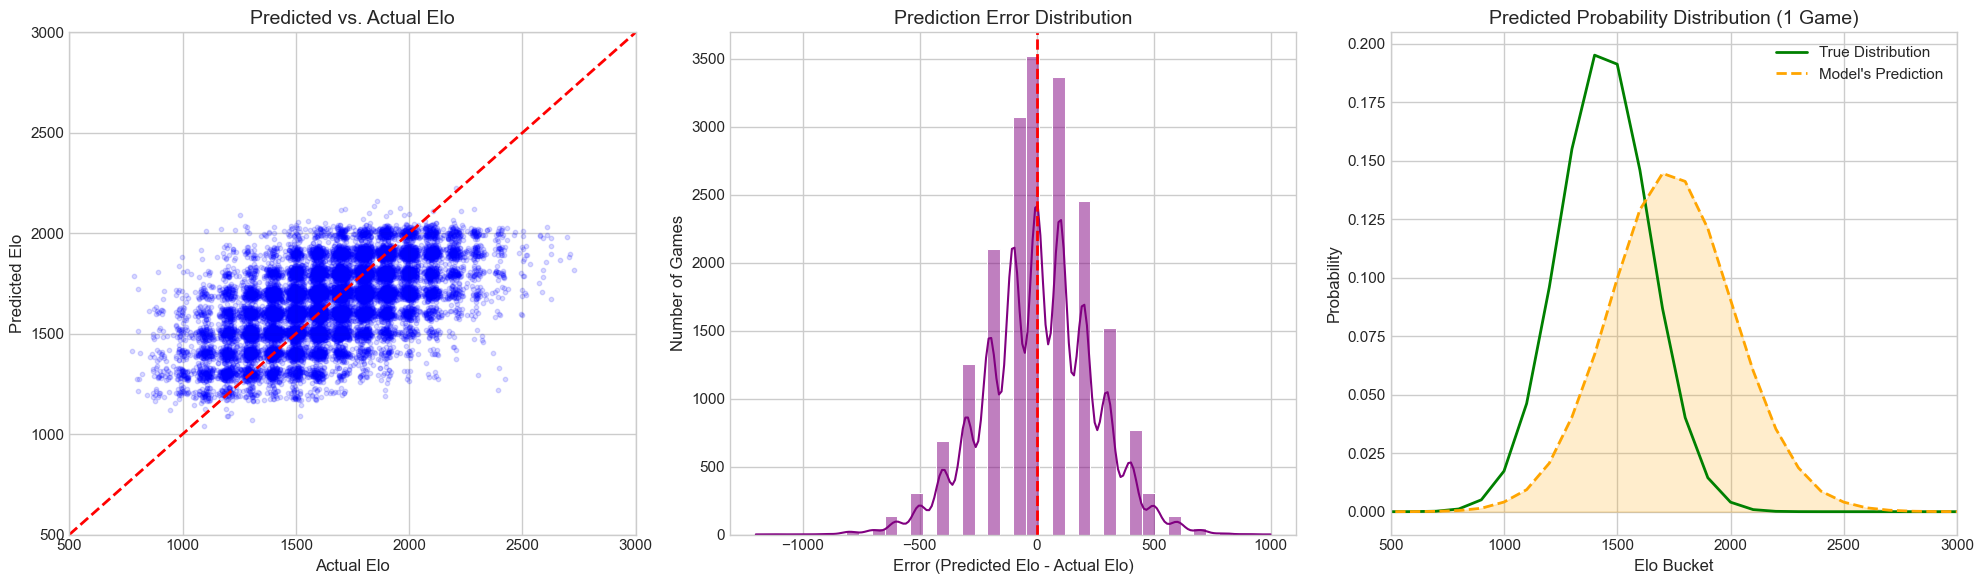

Final Mean Absolute Error (MAE): ±179 Elo points

--- Interpretation of Plots ---
1. The first plot shows how closely the model's predictions match the actual Elo ratings. The closer the blue dots are to the red dashed line, the better the predictions.
2. The second plot shows the distribution of prediction errors. Ideally, we want most errors to be close to zero, which would indicate that the model is generally accurate. A wide spread or a skewed distribution could indicate bias or inconsistency in predictions. The purple bars show how many games had a certain level of error, while the red dashed line at zero indicates perfect predictions. and the purple line shows the overall shape of the error distribution.
3. The third plot shows the predicted probability distribution for a single game compared to the true distribution. The closer the orange dashed line is to the green line, the better the model's understanding of that specific game's Elo rating.


In [26]:
# Set up a 1x3 grid for our plots
from sklearn.metrics import roc_auc_score, roc_curve


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# PLOT 1: Predicted vs. Actual Scatter Plot
# ---------------------------------------------------------
# We add a tiny bit of "jitter" (noise) to the scatter plot so the dots don't completely overlap
jittered_true = all_true_elos + np.random.normal(0, 20, size=len(all_true_elos))
jittered_pred = all_pred_elos + np.random.normal(0, 20, size=len(all_pred_elos))

axes[0].scatter(jittered_true, jittered_pred, alpha=0.15, color='blue', s=10)

# Draw the "Perfect Prediction" diagonal line
min_val, max_val = 500, 3000
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

axes[0].set_title('Predicted vs. Actual Elo', fontsize=14)
axes[0].set_xlabel('Actual Elo')
axes[0].set_ylabel('Predicted Elo')
axes[0].set_xlim(min_val, max_val)
axes[0].set_ylim(min_val, max_val)

# ---------------------------------------------------------
# PLOT 2: Error Distribution (Residuals)
# ---------------------------------------------------------
# Error = Predicted - Actual. If Error is positive, model guessed too high.
errors = all_pred_elos - all_true_elos

sns.histplot(errors, bins=40, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2) # Center line at 0 error

axes[1].set_title('Prediction Error Distribution', fontsize=14)
axes[1].set_xlabel('Error (Predicted Elo - Actual Elo)')
axes[1].set_ylabel('Number of Games')

# ---------------------------------------------------------
# PLOT 3: Single Game Probability Distribution (The Bell Curve)
# ---------------------------------------------------------
buckets = np.arange(0, 4000, 100)

axes[2].plot(buckets, sample_true_dist, label="True Distribution", color='green', linewidth=2)
axes[2].plot(buckets, sample_pred_dist, label="Model's Prediction", color='orange', linewidth=2, linestyle='--')
axes[2].fill_between(buckets, sample_pred_dist, alpha=0.2, color='orange')

axes[2].set_title('Predicted Probability Distribution (1 Game)', fontsize=14)
axes[2].set_xlabel('Elo Bucket')
axes[2].set_ylabel('Probability')
axes[2].set_xlim(500, 3000)
axes[2].legend()

plt.tight_layout()
plt.show()

# Calculate and print final metrics
mae = np.mean(np.abs(errors))
print(f"Final Mean Absolute Error (MAE): ±{mae:.0f} Elo points")
#Explain what each plot means in a print statement
print("\n--- Interpretation of Plots ---")
print("1. The first plot shows how closely the model's predictions match the actual Elo ratings. The closer the blue dots are to the red dashed line, the better the predictions.")
print("2. The second plot shows the distribution of prediction errors. Ideally, we want most errors to be close to zero, which would indicate that the model is generally accurate. A wide spread or a skewed distribution could indicate bias or inconsistency in predictions. The purple bars show how many games had a certain level of error, while the red dashed line at zero indicates perfect predictions. and the purple line shows the overall shape of the error distribution.")
print("3. The third plot shows the predicted probability distribution for a single game compared to the true distribution. The closer the orange dashed line is to the green line, the better the model's understanding of that specific game's Elo rating.")



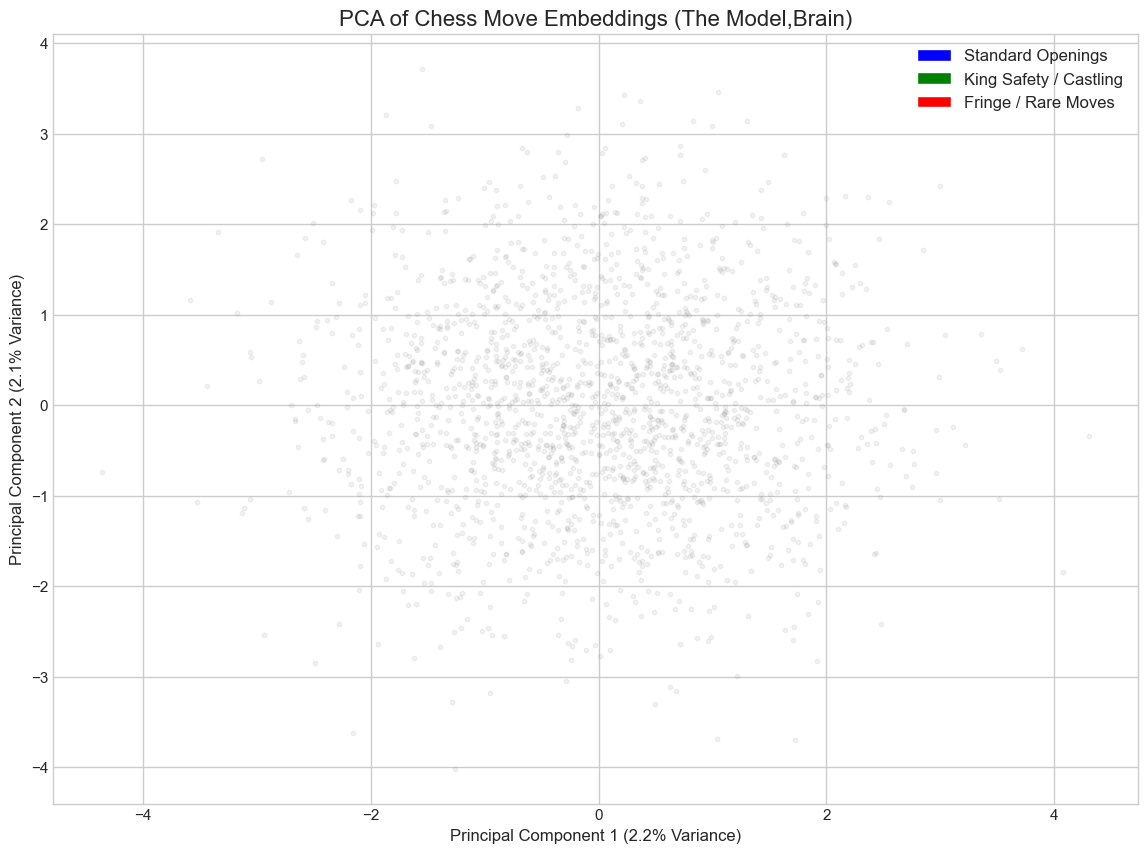

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Load the trained embeddings from your best model
model.load_state_dict(torch.load('distribution_chess_model.pth'))
# Extract the 1910 x 64 embedding matrix
embeddings = model.embedding.weight.detach().cpu().numpy()

# 2. Run PCA to reduce the 64 dimensions down to 2 dimensions (X and Y coordinates)
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# 3. Prepare the plot
plt.figure(figsize=(14, 10))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot all moves as light gray background dots
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.1, color='gray', s=10)

# 4. Define specific move categories we want to look for!
# You can change these to any standard PGN moves you want to investigate
opening_moves = ['e4', 'd4', 'c4', 'Nf3', 'e5', 'c5']
king_safety = ['O-O', 'O-O-O', 'Kh1', 'Kh8', 'Kg1', 'Kg8']
blunders_or_rare = ['h4', 'a4', 'Na3', 'Nh3', 'h5', 'a5']

def plot_highlighted_moves(move_list, color, label_prefix):
    for move in move_list:
        if move in vocab.move_to_id:
            idx = vocab.move_to_id[move]
            x, y = embeddings_2d[idx, 0], embeddings_2d[idx, 1]
            plt.scatter(x, y, color=color, s=50, edgecolors='black', zorder=5)
            plt.text(x + 0.02, y + 0.02, move, fontsize=12, weight='bold', color=color)

# Highlight our categories
plot_highlighted_moves(opening_moves, 'blue', 'Openings')
plot_highlighted_moves(king_safety, 'green', 'King Moves')
plot_highlighted_moves(blunders_or_rare, 'red', 'Edge Pawns/Knights')

plt.title('PCA of Chess Move Embeddings (The Model,Brain)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Standard Openings'),
                   Patch(facecolor='green', label='King Safety / Castling'),
                   Patch(facecolor='red', label='Fringe / Rare Moves')]
plt.legend(handles=legend_elements, loc='best', fontsize=12)

plt.show()